In [1]:
import numpy as np
import moments 
import dpluspy
import matplotlib.pyplot as plt 
import matplotlib 
import msprime
import demes 
import demesdraw
import moments
import scipy
from matplotlib.transforms import ScaledTranslation
import tskit


matplotlib.rcParams["font.size"] = 10
matplotlib.rcParams['xtick.labelsize'] = 8
matplotlib.rcParams['ytick.labelsize'] = 8
matplotlib.rcParams['ytick.major.size'] = 2
graph_color = "seagreen"

In [2]:
def label_axs(fig, axs):
    # label mosaic subplots 
    for label, ax in axs.items():
        ax.text(0.0, 1.0, label, fontsize="medium", va="bottom", transform=(
            ax.transAxes + ScaledTranslation(-20/72, +0/72, fig.dpi_scale_trans)))
    return


def label_ax(ax, label):
    ax.text(0.0, 1.0, label, fontsize="large", va="bottom", transform=(
        ax.transAxes + ScaledTranslation(-20/72, 4/72, fig.dpi_scale_trans)))
    return

In [3]:
# ghost introgression: effect of N_ghost on ED+ in sampled lineages.


def get_isolation_model():
    builder = demes.Builder(time_units="generations")
    builder.add_deme("anc", epochs=[{"start_size": 10000, "end_time": 2e4}])
    builder.add_deme("sample1", ancestors=["anc"],
        epochs=[{"start_size": 3e3, "end_time": 2000}])
    builder.add_deme("sample2", ancestors=["anc"],
        epochs=[{"start_size": 3e4, "end_time": 0}])
    return builder.resolve()


def get_ghost_model(N_ghost, f):
    builder = demes.Builder(time_units="generations")
    builder.add_deme("anc", epochs=[{"start_size": 10000, "end_time": 2e4}])
    builder.add_deme("ghost", start_time=4e4, ancestors=["anc"],
        epochs=[{"start_size": N_ghost, "end_time": 2e4}])
    builder.add_deme("sample1", start_time=2e4, ancestors=["anc", "ghost"], proportions=[1 - f, f],
        epochs=[{"start_size": 3e3, "end_time": 2000}])
    builder.add_deme("sample2", ancestors=["anc"],
        epochs=[{"start_size": 3e4, "end_time": 0}])
    return builder.resolve()


bins = np.logspace(-6, -2, 30)
rhos = bins * 4 * 1e4
base_model = dpluspy.inference.compute_bin_stats(get_isolation_model(), sampled_demes=["sample1", "sample2"], bins=bins, u=1.3e-8)
model_1k_1 = dpluspy.inference.compute_bin_stats(get_ghost_model(1e3, 0.01), sampled_demes=["sample1", "sample2"], bins=bins, u=1.3e-8)
model_10k_1 = dpluspy.inference.compute_bin_stats(get_ghost_model(1e4, 0.01), sampled_demes=["sample1", "sample2"], bins=bins, u=1.3e-8)
model_100k_1 = dpluspy.inference.compute_bin_stats(get_ghost_model(1e5, 0.01), sampled_demes=["sample1", "sample2"], bins=bins, u=1.3e-8)
model_1k_10 = dpluspy.inference.compute_bin_stats(get_ghost_model(1e3, 0.1), sampled_demes=["sample1", "sample2"], bins=bins, u=1.3e-8)
model_10k_10 = dpluspy.inference.compute_bin_stats(get_ghost_model(1e4, 0.1), sampled_demes=["sample1", "sample2"], bins=bins, u=1.3e-8)
model_100k_10 = dpluspy.inference.compute_bin_stats(get_ghost_model(1e5, 0.1), sampled_demes=["sample1", "sample2"], bins=bins, u=1.3e-8)

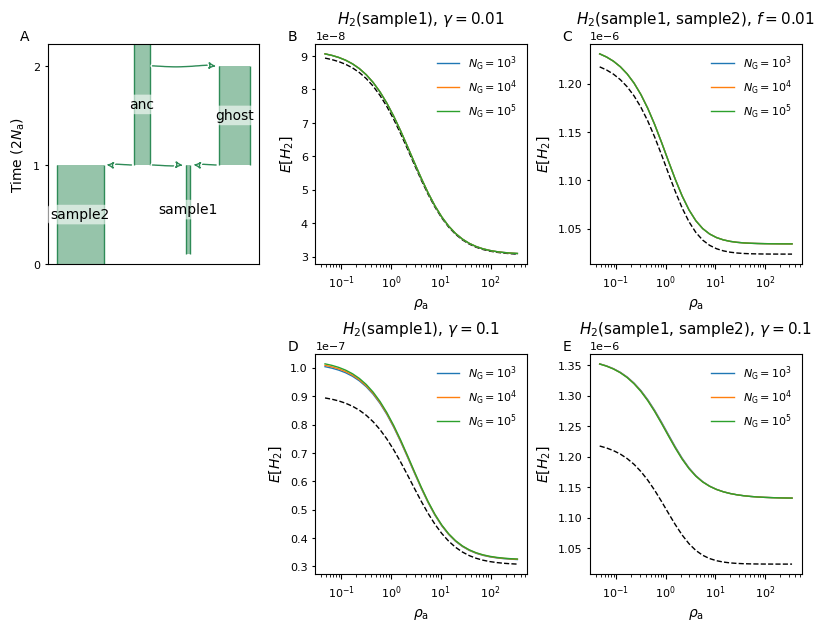

In [4]:
def plot_demography(ax):
    graph = get_ghost_model(2e4, 0.01)
    demesdraw.tubes(
        graph, ax=ax, colours=graph_color, fill=True, labels="mid", inf_ratio=0.1,
        positions={"anc": 0, "sample2": -4e4, "sample1": 3e4, "ghost": 6e4})
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_yticks([0, 2e4, 4e4], [0, 1, 2])
    ax.set_ylabel(r"Time ($2N_\text{a}$)")
    return


def make_panel_b(ax):
    dpluspy.plotting.plot_model_on_ax(
        ax, base_model, rhos, "D+_0_0", None, color="black", linestyle="--")
    dpluspy.plotting.plot_model_on_ax(
        ax, model_1k_1, rhos, "D+_0_0", r"$N_\text{G}=10^3$", color="tab:blue")
    dpluspy.plotting.plot_model_on_ax(
        ax, model_10k_1, rhos, "D+_0_0", r"$N_\text{G}=10^4$", color="tab:orange")
    dpluspy.plotting.plot_model_on_ax(
        ax, model_100k_1, rhos, "D+_0_0", r"$N_\text{G}=10^5$", color="tab:green")
    ax.set_xscale("log")
    ax.set_ylabel(r"$E[H_2]$")
    ax.set_xlabel(r"$\rho_\text{a}$")
    ax.set_title(r"$H_2$(sample1), $\gamma=0.01$")
    ax.legend(framealpha=0)
    return


def make_panel_c(ax):
    dpluspy.plotting.plot_model_on_ax(
        ax, base_model, rhos, "D+_0_1", None, color="black", linestyle="--")
    dpluspy.plotting.plot_model_on_ax(
        ax, model_1k_1, rhos, "D+_0_1", r"$N_\text{G}=10^3$", color="tab:blue")
    dpluspy.plotting.plot_model_on_ax(
        ax, model_10k_1, rhos, "D+_0_1", r"$N_\text{G}=10^4$", color="tab:orange")
    dpluspy.plotting.plot_model_on_ax(
        ax, model_100k_1, rhos, "D+_0_1", r"$N_\text{G}=10^5$", color="tab:green")
    ax.set_xscale("log")
    ax.set_ylabel(r"$E[H_2]$")
    ax.set_xlabel(r"$\rho_\text{a}$")
    ax.set_title(r"$H_2$(sample1, sample2), $\gamma=0.01$")
    ax.legend(framealpha=0)
    return


def make_panel_d(ax):
    dpluspy.plotting.plot_model_on_ax(
        ax, base_model, rhos, "D+_0_0", None, color="black", linestyle="--")
    dpluspy.plotting.plot_model_on_ax(
        ax, model_1k_10, rhos, "D+_0_0", r"$N_\text{G}=10^3$", color="tab:blue")
    dpluspy.plotting.plot_model_on_ax(
        ax, model_10k_10, rhos, "D+_0_0", r"$N_\text{G}=10^4$", color="tab:orange")
    dpluspy.plotting.plot_model_on_ax(
        ax, model_100k_10, rhos, "D+_0_0", r"$N_\text{G}=10^5$", color="tab:green")
    ax.set_xscale("log")
    ax.set_ylabel(r"$E[H_2]$")
    ax.set_xlabel(r"$\rho_\text{a}$")
    ax.set_title(r"$H_2$(sample1), $\gamma=0.1$")
    ax.legend(framealpha=0)
    return


def make_panel_e(ax):
    dpluspy.plotting.plot_model_on_ax(
        ax, base_model, rhos, "D+_0_1", None, color="black", linestyle="--")
    dpluspy.plotting.plot_model_on_ax(
        ax, model_1k_10, rhos, "D+_0_1", r"$N_\text{G}=10^3$", color="tab:blue")
    dpluspy.plotting.plot_model_on_ax(
        ax, model_10k_10, rhos, "D+_0_1", r"$N_\text{G}=10^4$", color="tab:orange")
    dpluspy.plotting.plot_model_on_ax(
        ax, model_100k_10, rhos, "D+_0_1", r"$N_\text{G}=10^5$", color="tab:green")
    ax.set_xscale("log")
    ax.set_ylabel(r"$E[H_2]$")
    ax.set_xlabel(r"$\rho_\text{a}$")
    ax.set_title(r"$H_2$(sample1, sample2), $\gamma=0.1$")
    ax.legend(framealpha=0)
    return


mosaic = "ABC;XDE"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(8, 6.2), layout="constrained")
axs["X"].remove()
label_axs(fig, axs)
plot_demography(axs["A"])
make_panel_b(axs["B"])
make_panel_c(axs["C"])
make_panel_d(axs["D"])
make_panel_e(axs["E"])
plt.savefig("figures/ghost_Ne_model.pdf")

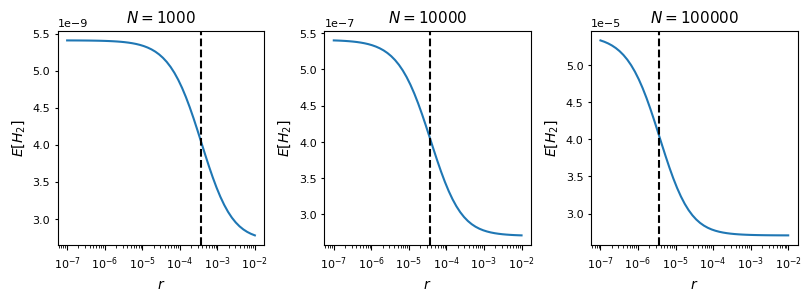

In [5]:
"""
plot effect of Ne on center of H_2 curve
"""


fig, axs = plt.subplot_mosaic("ABC", figsize=(8, 2.9), layout="constrained", sharex=True)

u = 1.3e-8
rs = np.logspace(-7, -2, 50)

Ns = [1e3, 1e4, 1e5]

for N, label in zip(Ns, axs):
    ax = axs[label]
    H2 = moments.LD.Demographics1D.snm(rho=4 * N * rs, theta=4 * N * u).H2(0)
    ax.plot(rs, H2)
    ax.set_xscale("log")
    center = 2.892 / (8 * N)
    ax.vlines(center, 0, 1, transform=ax.get_xaxis_transform(), color="black", linestyle="--")
    ax.set_title(f"$N = {int(N)}$")
    ax.set_xlabel("$r$")
    ax.set_ylabel("$E[H_2]$")
plt.savefig("figures/Ne_comparison.pdf")

In [19]:
Nref = 1e4

def get_structure_model(params):
    vX, vY, v1, t0, t1, f, M = params
    NX = Nref * vX
    NY = Nref * vY 
    N1 = Nref * v1 
    T0 = 2 * Nref * t0 
    T1 = 2 * Nref * t1
    m = M / (4 * Nref)
    builder = demes.Builder()
    builder.add_deme("Anc", epochs=[{"start_size": Nref, "end_time": T0}])
    builder.add_deme("X", ancestors=["Anc"], 
                     epochs=[{"start_size": NX, "end_time": T1}])
    builder.add_deme("Y", ancestors=["Anc"], 
                     epochs=[{"start_size": NY, "end_time": T1}])
    builder.add_deme("A", ancestors=["X", "Y"], proportions=[f, 1 - f],
                     start_time=T1, 
                     epochs=[{"start_size": N1, "end_time": 0}])
    if m > 0:
        builder.add_migration(rate=m, demes=["X", "Y"])
    graph = builder.resolve()
    return graph


def compute_rate_trajectory(graph, ts, sample):
    demog = msprime.Demography.from_demes(graph)
    debug = demog.debug()
    rates, _ = debug.coalescence_rate_trajectory(ts, {sample: 2})
    return rates


def get_panmictic_model(ts, rates):
    Nes = 1 / (2 * np.array(rates))
    _ts = np.flip(ts)
    _Nes = np.flip(Nes)
    epochs = [
        {"start_size": Ne, "end_time": t} for Ne, t in zip(_Nes, _ts)
    ]
    builder = demes.Builder()
    builder.add_deme("A", epochs=epochs)
    graph = builder.resolve()
    return graph


_models_cache = {}


def get_model_curves(params, rs, u=1e-8, n_ts=50):
    model_key = (tuple(params), tuple(list(rs)), u, n_ts)
    if model_key in _models_cache:
        struc_exp, panmix_exp = _models_cache[model_key]
        return struc_exp, panmix_exp
    T0 = params[3] * 2 * Nref
    ts = np.linspace(0, T0 * 1.05, n_ts)
    struc_model = get_structure_model(params)
    struc_exp = moments.Demes.LD(
        struc_model, sampled_demes=["A"], r=rs, u=u).H2(0)
    rates = compute_rate_trajectory(struc_model, ts, "A")
    panmix_model = get_panmictic_model(ts, rates)
    panmix_exp = moments.Demes.LD(
        panmix_model, sampled_demes=["A"], r=rs, u=u).H2(0)
    _models_cache[model_key] = (struc_exp, panmix_exp)
    return struc_exp, panmix_exp


colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple"
]


def plot_strucpanel(
    ax, 
    params_s, 
    labels,
    rs, 
    u=1e-8, 
    n_ts=50, 
    struc_kwargs={}, 
    pan_kwargs={}
):
    """
    Plot a comparison of panmictic/structured model expectations
    :param params_s: list of lists/tuples holding parameters for struc. model
    """
    rhos = 4 * Nref * rs
    for ii, params in enumerate(params_s):
        color = colors[ii]
        label = labels[ii]
        struc_exp, panmix_exp = get_model_curves(params, rs, u=u, n_ts=n_ts)
        ax.plot(rhos, struc_exp, color=color, label=label,  
                **struc_kwargs)
        #ax.plot(rhos, panmix_exp, "--", color=color,  **pan_kwargs)
        ax.plot(rhos, panmix_exp, "--o", color=color, 
                markersize=2.5, **pan_kwargs)
        #ax.scatter(rhos, panmix_exp, color=color, s=10, lw=lw)
    ax.set_xscale("log")
    ax.minorticks_off()
    ax.legend(framealpha=0, fontsize="x-small")
    ax.set_ylabel(r"$E[H_2]$")
    ax.set_xlabel(r"$\rho_\text{A}$")
    return


example_params = (0.5, 0.5, 1, 1.1, 0.1, 0.5, 1e-8)


def plot_schematic_model(ax):
    model = get_structure_model(example_params)
    demesdraw.tubes(
        model,
        positions={"Anc": 0, "A": 0, "X": -1.4e4, "Y": 1.4e4},
        num_lines_per_migration=4,
        colours=graph_color,
        ax=ax,
        labels=None
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_ylabel(r"Time ($2N_\text{A}$)")
    ax.set_yticks([0, 2.5e4, 5e3], [0, "$T_0$", "$T_1$"])
    ax.text(0, 23000, "$N_A$", fontsize="small", horizontalalignment="center")
    ax.text(0, 11000, "$M$", fontsize="small", horizontalalignment="center")
    ax.text(-14500, 11000, "$N_X$", fontsize="small", horizontalalignment="center")
    ax.text(14500, 11000, "$N_Y$", fontsize="small", horizontalalignment="center")
    ax.text(0, 500, "$N_1$", fontsize="small", horizontalalignment="center")
    ax.text(-9000, 500, r"$\gamma$", fontsize="small", horizontalalignment="center")
    ax.set_xlim(-2.2e4, 2.2e4)
    return 


def plot_schematic_panmix_model(ax):
    _model = get_structure_model(example_params)
    ts = np.linspace(0, 2.22e4, 21)
    rates = compute_rate_trajectory(_model, ts, "A")
    model = get_panmictic_model(ts, rates)
    demesdraw.tubes(
        model,
        positions={"A": 0},
        num_lines_per_migration=4,
        colours=graph_color,
        ax=ax,
        labels=None,
        inf_ratio=0.1
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_ylabel(r"Time ($2N_\text{A}$)")
    ax.set_yticks([0, 2.2e4, 2e3], [0, "$T_0$", "$T_1$"])
    ax.text(0, 23000, "$N_A$", fontsize="small", horizontalalignment="center")
    ax.text(0, 500, "$N_1$", fontsize="small", horizontalalignment="center")
    ax.set_xlim(-2.2e4, 2.2e4)
    return 


def plot_coal_rates(ax):
    ts = np.linspace(0, 2.5e4, 101)
    _ts = np.linspace(0, 2.5e4, 21)
    struc_model = get_structure_model(example_params)
    rates = compute_rate_trajectory(struc_model, ts, "A") 
    panmix_model = get_panmictic_model(ts, rates)
    pan_rates = compute_rate_trajectory(panmix_model, _ts, "A")
    ax.plot(ts, rates * 2e4, color="tab:blue",  label="structured")
    ax.scatter(_ts, pan_rates * 2e4, color="tab:blue", s=10)
    ax.plot([], [], "--o", color="tab:blue",  label="panmictic", 
            markersize=2.5)
    ax.legend(framealpha=0, fontsize="small")
    ax.set_ylabel(r"$\lambda(t)\times 2N_\text{A}$")
    ax.set_xlabel(r"Time ($2N_\text{A}$)")
    ax.set_xticks([2.2e4, 2e3], ["$T_0$", "$T_1$"])
    ax.set_ylim(0,)
    return

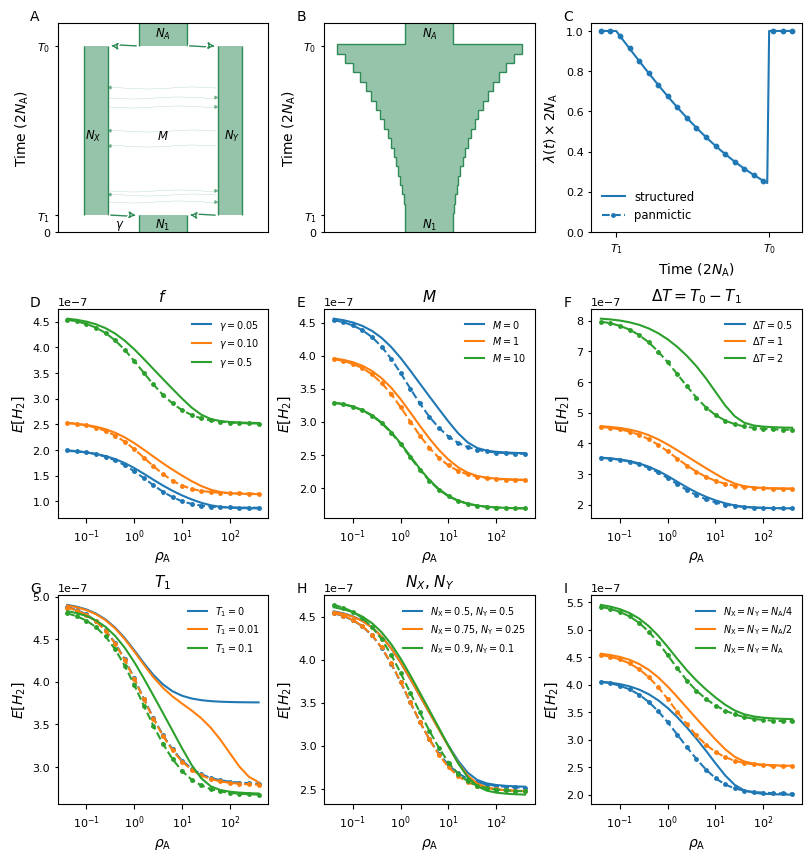

In [11]:
rs = np.logspace(-6, -2, 21)
mosaic = "ABC;DEF;GHI"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(8, 8.5), layout="constrained")
label_axs(fig, axs)
plot_schematic_model(axs["A"])
plot_schematic_panmix_model(axs["B"])
axs["A"].sharey(axs["B"])
plot_coal_rates(axs["C"])

# vX, vY, v1, t0, t1, f, M = params

# default parameters
vX0 = 0.5
vY0 = 0.5
v10 = 1
t00 = 1.1
t10 = 0.1
f0 = 0.5
M0 = 0

params = [
    (vX0, vY0, v10, t00, t10, 0.05, M0),
    (vX0, vY0, v10, t00, t10, 0.1, M0),
    (vX0, vY0, v10, t00, t10, 0.5, M0),
]
labels = [
    r"$\gamma=0.05$",
    r"$\gamma=0.10$",
    r"$\gamma=0.5$",
]
plot_strucpanel(axs["D"], params, labels, rs, n_ts=50)
axs["D"].set_title("$f$")


params = [
    (vX0, vY0, v10, t00, t10, f0, 0),
    (vX0, vY0, v10, t00, t10, f0, 1),
    (vX0, vY0, v10, t00, t10, f0, 10),
]
labels = [
    r"$M=0$",
    r"$M=1$",
    r"$M=10$",
]
plot_strucpanel(axs["E"], params, labels, rs, n_ts=50)
axs["E"].set_title("$M$")


params = [
    (vX0, vY0, v10, 0.6, t10, f0, M0),
    (vX0, vY0, v10, 1.1, t10, f0, M0),
    (vX0, vY0, v10, 2.1, t10, f0, M0),
]
labels = [
    r"$\Delta T=0.5$",
    r"$\Delta T=1$",
    r"$\Delta T=2$",
]
plot_strucpanel(axs["F"], params, labels, rs, n_ts=50)
axs["F"].set_title(r"$\Delta T = T_0-T_1$")


params = [    
    (vX0, vY0, v10, t00 + 1e-10, 1e-10, f0, M0),
    (vX0, vY0, v10, t00 + 1e-2, 1e-2, f0, M0),
    (vX0, vY0, v10, t00 + 0.1, 0.1, f0, M0),
]
labels = [
    "$T_1=0$",
    "$T_1=0.01$",
    "$T_1=0.1$"
]
plot_strucpanel(axs["G"], params, labels, rs, n_ts=50)
axs["G"].set_title(r"$T_1$")


params = [
    (0.5, 0.5, v10, t00, t10, f0, M0),
    (0.75, 0.25, v10, t00, t10, f0, M0),
    (0.9, 0.1, v10, t00, t10, f0, M0),
]
labels = [
    r"$N_\text{X}=0.5$, $N_\text{Y}=0.5$",
    r"$N_\text{X}=0.75$, $N_\text{Y}=0.25$",
    r"$N_\text{X}=0.9$, $N_\text{Y}=0.1$",
]
plot_strucpanel(axs["H"], params, labels, rs, n_ts=50)
axs["H"].set_title(r"$N_X$, $N_Y$")


params = [
    (0.25, 0.25, v10, t00, t10, f0, M0),
    (vX0, vY0, v10, t00, t10, f0, M0),
    (1, 1, v10, t00, t10, f0, M0),
]
labels = [
    r"$N_\text{X} = N_\text{Y} = N_\text{A}/4$",
    r"$N_\text{X} = N_\text{Y} = N_\text{A}/2$",
    r"$N_\text{X} = N_\text{Y} = N_\text{A}$",
]
plot_strucpanel(axs["I"], params, labels, rs, n_ts=50)
axs["H"].set_title(r"$N_X$, $N_Y$")


plt.savefig("figures/structure_models.pdf")

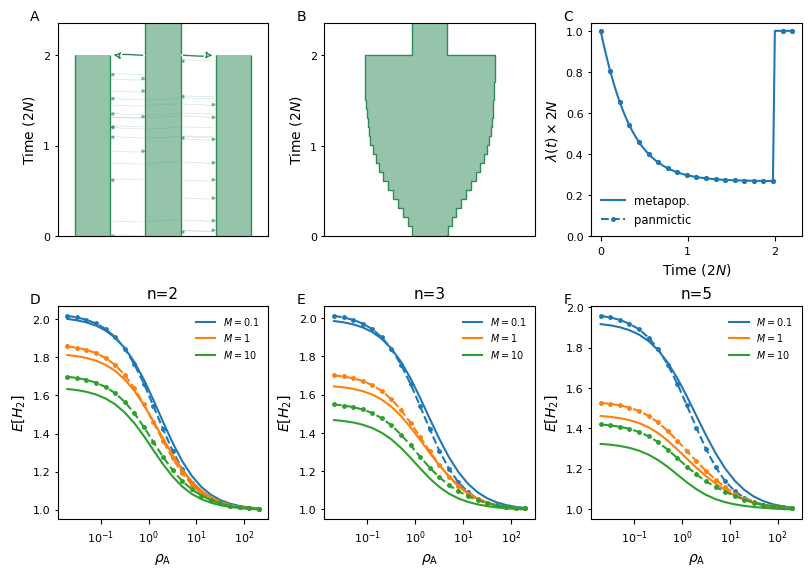

In [38]:
"""
metapopulation model plot
"""

Ne = Nref = 5e3
T = 2 * 2  * Ne


def get_metapopulation_model(params):
    # get a stationary metapopulation model
    N, n, M = params
    m = M / (4 * N)
    builder = demes.Builder()
    builder.add_deme(
        "A", 
        epochs=[{"start_size": N, "end_time": T}]
    )
    for i in range(n):
        builder.add_deme(
            f"D{i}", 
            ancestors=["A"],         
            epochs=[{"start_size": N, "end_time": 0}]
        )
    for i in range(n):
        for j in range(i + 1, n):
            builder.add_migration(rate=m, demes=[f"D{i}", f"D{j}"])
    graph = builder.resolve()
    return graph


def plot_schematic_model(ax):
    model = get_metapopulation_model([Ne, 3, 0.1])
    demesdraw.tubes(
        model,
        positions={"A": 0, "D0": -1e4, "D1": 0, "D2": 1e4},
        num_lines_per_migration=4,
        colours=graph_color,
        ax=ax,
        labels=None,
       # log_time=True,
        inf_ratio=0.15
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_ylabel(r"Time ($2N$)")
    ax.set_ylim(100, )
    # ax.set_yticks([0, 20 * Ne], [0, 10])
    #ax.text(0, 4e3, "$N$", fontsize="small", horizontalalignment="center")
    #ax.text(-5e3, 5e3, "$M$", fontsize="small", horizontalalignment="center")
    #ax.text(5e3, 5e3, "$M$", fontsize="small", horizontalalignment="center")
    # ax.text(-14500, 11000, "$N_X$", fontsize="small", horizontalalignment="center")
    # ax.text(14500, 11000, "$N_Y$", fontsize="small", horizontalalignment="center")
    # ax.text(0, 500, "$N_1$", fontsize="small", horizontalalignment="center")
    # ax.text(-9000, 500, "$f$", fontsize="small", horizontalalignment="center")
    yticks = np.array([0, 1, 2])
    ax.set_yticks(yticks * 2 * Ne, yticks)
    ax.set_xlim(-1.5e4, 1.5e4)
    return 
    

def plot_schematic_panmix_model(ax):
    _model = get_metapopulation_model([Ne, 3, 1])
    ts = np.concatenate([[0], np.linspace(100, T, 21), [T * 1.001]])
    rates = compute_rate_trajectory(_model, ts, "D0")
    model = get_panmictic_model(ts, rates)
    demesdraw.tubes(
        model,
        positions={"A": 0},
        num_lines_per_migration=4,
        colours=graph_color,
        ax=ax,
        labels=None,
        # log_time=True,
        inf_ratio=0.15
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_ylabel(r"Time ($2N$)")
    ax.set_ylim(100, )
    #ax.text(0, 1.4e5, "$N$", fontsize="small", horizontalalignment="center")
    # ax.text(0, 500, r"$\approx N$", fontsize="small", horizontalalignment="center")
    yticks = np.array([0, 1, 2])
    ax.set_yticks(yticks * 2 * Ne, yticks)
    ax.set_xlim(-1.5e4, 1.5e4)
    return 


def get_model_curves(params, rs, u=1e-8, n_ts=50):
    model_key = (tuple(params), tuple(list(rs)), u, n_ts)
    if model_key in _models_cache:
        meta_exp, panmix_exp = _models_cache[model_key]
        return meta_exp, panmix_exp
    ts = np.linspace(0, 1.05e5, 101)
    meta_model = get_metapopulation_model(params)
    yy = moments.Demes.LD(meta_model, sampled_demes=["D0"], r=rs, u=u)
    meta_exp = yy.H2(0) / yy.H()[0] ** 2
    
    rates = compute_rate_trajectory(meta_model, ts, "D0")
    panmix_model = get_panmictic_model(ts, rates)
    yy = moments.Demes.LD(panmix_model, sampled_demes=["A"], r=rs, u=u)
    panmix_exp = yy.H2(0) / yy.H()[0] ** 2
    _models_cache[model_key] = (meta_exp, panmix_exp)
    return meta_exp, panmix_exp


colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple"
]


def plot_panel(
    ax, 
    params_s, 
    labels,
    rs, 
    u=1e-8, 
    n_ts=50, 
    struc_kwargs={}, 
    pan_kwargs={}
):
    """
    Plot a comparison of panmictic/structured model expectations
    :param params_s: list of lists/tuples holding parameters for struc. model
    """
    rhos = 4 * Nref * rs
    for ii, params in enumerate(params_s):
        color = colors[ii]
        label = labels[ii]
        meta_exp, panmix_exp = get_model_curves(params, rs, u=u, n_ts=n_ts)
        ax.plot(rhos, meta_exp, color=color, label=label,  
                **struc_kwargs)
        ax.plot(rhos, panmix_exp, "--o", color=color, 
                markersize=2.5, **pan_kwargs)    
    ax.set_xscale("log")
    ax.minorticks_off()
    ax.legend(framealpha=0, fontsize="x-small")
    ax.set_ylabel(r"$E[\sigma_{H_2}]$")
    ax.set_xlabel(r"$\rho_\text{A}$")
    return


def plot_coal_rates(ax):
    ts = np.linspace(0, T * 1.1, 101)
    _ts = np.linspace(0, T * 1.1, 21)
    meta_model = get_metapopulation_model((Ne, 3, 1))
    rates = compute_rate_trajectory(meta_model, ts, "D0") 
    panmix_model = get_panmictic_model(ts, rates)
    pan_rates = compute_rate_trajectory(panmix_model, _ts, "A")
    ax.plot(ts, rates * 2 * Ne, color="tab:blue",  label="metapop.")
    ax.plot([], [], "--o", color="tab:blue", markersize=2.5, label="panmictic")
    ax.scatter(_ts, pan_rates * 2 * Ne, color="tab:blue", s=7.5)
    ax.legend(framealpha=0, fontsize="small")
    ax.set_ylabel(r"$\lambda(t)\times 2N$")
    ax.set_xlabel(r"Time ($2N$)")
    xticks = np.array([0, 1, 2])
    ax.set_xticks(xticks * 2 * Ne, xticks)
    ax.set_ylim(0,)
    return


rs = np.logspace(-6, -2, 21)
mosaic = "ABC;DEF"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(8, 5.65), layout="constrained")
label_axs(fig, axs)
plot_schematic_model(axs["A"])
plot_schematic_panmix_model(axs["B"])
plot_coal_rates(axs["C"])


params = [
    (Ne, 2, 0.1),
    (Ne, 2, 1),
    (Ne, 2, 10),
]
labels = [
    "$M=0.1$",
    "$M=1$",
    "$M=10$",
]
plot_strucpanel(axs["D"], params, labels, rs, n_ts=50)
axs["D"].set_title("n=2")


params = [
    (Ne, 3, 0.1),
    (Ne, 3, 1),
    (Ne, 3, 10),
]
labels = [
    "$M=0.1$",
    "$M=1$",
    "$M=10$",
]
plot_strucpanel(axs["E"], params, labels, rs, n_ts=50)
axs["E"].set_title("n=3")


params = [
    (Ne, 5, 0.1),
    (Ne, 5, 1),
    (Ne, 5, 10),
]
labels = [
    "$M=0.1$",
    "$M=1$",
    "$M=10$",
]
plot_strucpanel(axs["F"], params, labels, rs, n_ts=50)
axs["F"].set_title("n=5")

plt.savefig("figures/metapopulation_models.pdf")

In [9]:
#
# merged metapopulation model with n demes
#


def get_metapopulation_model(params):
    # parameters are N, n, T0, T1, M, "merged", "ring"
    N, n, T0, T1, M, merged, ring = params
    Ni = N / n
    t0 = 2 * N * T0 
    t1 = 2 * N * T1
    m = M / (4 * Ni)
    builder = demes.Builder()
    builder.add_deme(
        "A", 
        epochs=[{"start_size": N, "end_time": t0}]
    )
    for i in range(n):
        builder.add_deme(
            f"D{i}", 
            ancestors=["A"],         
            epochs=[{"start_size": Ni, "end_time": t1}]
        )

    if merged:
        builder.add_deme(
            "X", 
            ancestors=[f"D{i}" for i in range(n)], 
            proportions=[1 / n for i in range(n)],
            start_time=t1, 
            epochs=[{"start_size": N, "end_time": 0}])
    else:
        builder.add_deme(
            "X", 
            ancestors=["D0"], 
            start_time=t1, 
            epochs=[{"start_size": N, "end_time": 0}])

    if ring:
        if n > 2:
            builder.add_migration(rate=m, demes=["D0", f"D{n-1}"])
        for i in range(n - 1):
            builder.add_migration(rate=m, demes=[f"D{i}", f"D{i+1}"])
    else:
        for i in range(n):
            for j in range(i + 1, n):
                builder.add_migration(rate=m, demes=[f"D{i}", f"D{j}"])
    graph = builder.resolve()
    return graph


def compute_rate_trajectory(graph, ts, sample):
    demog = msprime.Demography.from_demes(graph)
    debug = demog.debug()
    rates, _ = debug.coalescence_rate_trajectory(ts, {sample: 2})
    return rates


def get_panmictic_model(ts, rates):
    Nes = 1 / (2 * np.array(rates))
    _ts = np.flip(ts)
    _Nes = np.flip(Nes)
    epochs = [
        {"start_size": Ne, "end_time": t} for Ne, t in zip(_Nes, _ts)
    ]
    builder = demes.Builder()
    builder.add_deme("A", epochs=epochs)
    graph = builder.resolve()
    return graph


_models_cache = {}


def get_model_curves(params, rs, u=1e-8, n_ts=50):
    model_key = (tuple(params), tuple(list(rs)), u, n_ts)
    if model_key in _models_cache:
        struc_exp, panmix_exp = _models_cache[model_key]
        return struc_exp, panmix_exp
    T0 = params[3] * 2 * Nref
    ts = np.linspace(0, T0 * 1.05, n_ts)
    struc_model = get_structure_model(params)
    struc_exp = moments.Demes.LD(
        struc_model, sampled_demes=["A"], r=rs, u=u).H2(0)
    rates = compute_rate_trajectory(struc_model, ts, "A")
    panmix_model = get_panmictic_model(ts, rates)
    panmix_exp = moments.Demes.LD(
        panmix_model, sampled_demes=["A"], r=rs, u=u).H2(0)
    _models_cache[model_key] = (struc_exp, panmix_exp)
    return struc_exp, panmix_exp


colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple"
]


def plot_strucpanel(
    ax, 
    params_s, 
    labels,
    rs, 
    u=1e-8, 
    n_ts=50, 
    struc_kwargs={}, 
    pan_kwargs={}
):
    """
    Plot a comparison of panmictic/structured model expectations
    :param params_s: list of lists/tuples holding parameters for struc. model
    """
    rhos = 4 * Nref * rs
    for ii, params in enumerate(params_s):
        color = colors[ii]
        label = labels[ii]
        struc_exp, panmix_exp = get_model_curves(params, rs, u=u, n_ts=n_ts)
        ax.plot(rhos, struc_exp, color=color, label=label,  
                **struc_kwargs)
        #ax.plot(rhos, panmix_exp, "--", color=color,  **pan_kwargs)
        ax.plot(rhos, panmix_exp, "--o", color=color, 
                markersize=2.5, **pan_kwargs)
        #ax.scatter(rhos, panmix_exp, color=color, s=10, lw=lw)
    ax.set_xscale("log")
    ax.minorticks_off()
    ax.legend(framealpha=0, fontsize="x-small")
    ax.set_ylabel(r"$E[D^+]$")
    ax.set_xlabel(r"$\rho$")
    return


example_params = (0.5, 0.5, 1, 1.1, 0.1, 0.5, 1e-8)


def plot_schematic_model(ax):
    model = get_structure_model(example_params)
    demesdraw.tubes(
        model,
        num_lines_per_migration=4,
        colours=graph_color,
        ax=ax,
        labels=None
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_ylabel(r"Time ($2N_\text{A}$)")
    ax.set_yticks([2.5e4, 5e3], ["$T_0$", "$T_1$"])
    ax.set_xlim(-2.2e4, 2.2e4)
    return 


def plot_schematic_panmix_model(ax):
    _model = get_structure_model(example_params)
    ts = np.linspace(0, 2.22e4, 21)
    rates = compute_rate_trajectory(_model, ts, "A")
    model = get_panmictic_model(ts, rates)
    demesdraw.tubes(
        model,
        positions={"A": 0},
        num_lines_per_migration=4,
        colours=graph_color,
        ax=ax,
        labels=None,
        inf_ratio=0.1
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_ylabel(r"Time ($2N_\text{A}$)")
    ax.set_yticks([2.2e4, 2e3], ["$T_0$", "$T_1$"])
    ax.text(0, 23000, "$N_A$", fontsize="small", horizontalalignment="center")
    ax.text(0, 500, "$N_1$", fontsize="small", horizontalalignment="center")
    ax.set_xlim(-2.2e4, 2.2e4)
    return 


def plot_coal_rates(ax):
    ts = np.linspace(0, 2.5e4, 101)
    _ts = np.linspace(0, 2.5e4, 21)
    struc_model = get_structure_model(example_params)
    rates = compute_rate_trajectory(struc_model, ts, "A") 
    panmix_model = get_panmictic_model(ts, rates)
    pan_rates = compute_rate_trajectory(panmix_model, _ts, "A")
    ax.plot(ts, rates * 2e4, color="tab:blue",  label="structured")
    ax.scatter(_ts, pan_rates * 2e4, color="tab:blue", s=10)
    ax.plot([], [], "--o", color="tab:blue",  label="panmictic", 
            markersize=2.5)
    ax.legend(framealpha=0, fontsize="small")
    ax.set_ylabel(r"$\lambda(t)\times 2N_\text{A}$")
    ax.set_xlabel(r"Time ($2N_\text{A}$)")
    ax.set_xticks([2.2e4, 2e3], ["$T_0$", "$T_1$"])
    return

FileNotFoundError: [Errno 2] No such file or directory: 'extra_figures/structure.png'

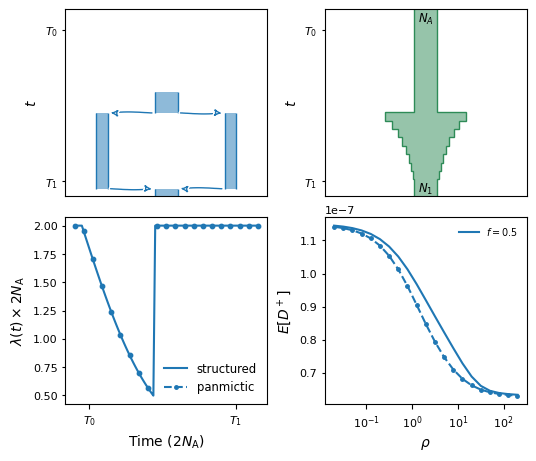

In [10]:
def plot_schematic_model(ax):
    model = get_structure_model(example_params)
    demesdraw.tubes(
        model,
        positions={"Anc": 0, "A": 0, "X": -1.4e4, "Y": 1.4e4},
        num_lines_per_migration=0,
        colours="tab:blue",
        ax=ax,
        labels=None
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_ylabel("$t$ (units of $2N_0$)")
    ax.set_yticks([2.5e4, 5e3], ["$T_0$", "$T_1$"])
    ax.set_xlim(-2.2e4, 2.2e4)
    return 

fig, axs = plt.subplots(2, 2, figsize=(5.25, 4.5), layout="constrained")
rs = np.logspace(-6, -2, 21)
axs = axs.flat
plot_schematic_model(axs[0])
plot_schematic_panmix_model(axs[1])
axs[0].sharey(axs[1])
axs[0].set_ylabel("$t$")
axs[1].set_ylabel("$t$")
plot_coal_rates(axs[2])
axs[2].set_xticks([2e3, 2.2e4], ["$T_0$", "$T_1$"])

params0 = [(0.5, 0.5, 1, 1.1, 0.1, 0.5, 0)]
labels0 = ["$f=0.5$"]
plot_strucpanel(axs[3], params0, labels0, rs, n_ts=50)

plt.savefig("extra_figures/structure.png", dpi=244)

In [11]:
def two_locus_sim(graph, samples, r, n):
    if isinstance(graph, str):
        graph = demes.load(graph)
    demography = msprime.Demography.from_demes(graph)
    ts_iter = msprime.sim_ancestry(
        samples=samples, 
        sequence_length=2, 
        recombination_rate=r,
        demography=demography,
        # model=msprime.DiscreteTimeWrightFisher(),
        num_replicates=n
    )
    t_array = np.zeros((n, 2))
    for ii, ts in enumerate(ts_iter):
        if ts.num_trees == 1:
            tree = next(iter(ts.trees()))
            t_array[ii, :] = tree.tmrca(0, 1)
        else:
            t_array[ii] = [tree.tmrca(0, 1) for tree in ts.trees()]
    return t_array


_cache = {}

def retrieve_sim(graph, samples, r, n):
    key = (str(graph), str(samples), r, n)
    if key in _cache:
        ret = _cache[key]
    else:
        ret = two_locus_sim(graph, samples, r, n)
        _cache[key] = ret
    return ret

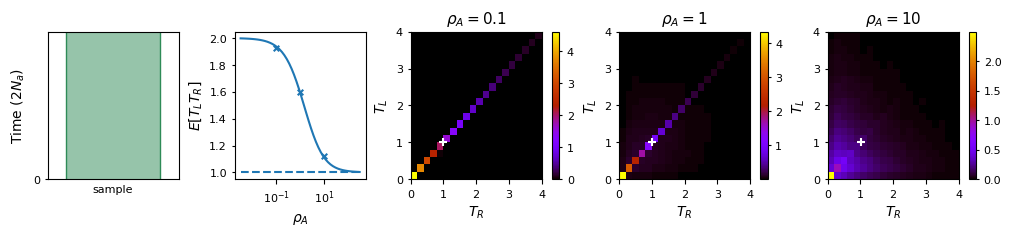

In [31]:
def plot_equilibrium_model(axs, fig):
    # takes an array of (5,) axs
    Na = 1e4
    builder = demes.Builder()
    builder.add_deme("sample", epochs=[{"start_size": Na, "end_time": 0}])
    graph = builder.resolve()

    # plot the graph
    demesdraw.tubes(graph, ax=axs[0], colours="seagreen", labels="xticks")
    axs[0].spines["top"].set_visible(True)
    axs[0].spines["right"].set_visible(True)
    axs[0].spines["bottom"].set_visible(True)
    axs[0].set_yticks([0], [0])
    axs[0].set_ylabel("Time ($2N_a$)")
    axs[0].set_xlim(-7e3, 7e3)

    # plot moments expectations
    rhos = np.logspace(-2.5, 2.5, 50)
    yy = moments.Demes.LD(graph, ["sample"], rho=rhos, u=1)
    TTs = yy.H2(0) / 4 / (2 * Na) ** 2
    axs[1].plot(rhos, TTs)
    axs[1].set_xscale("log")
    axs[1].set_ylabel(r"$E[T_L T_R]$")
    axs[1].set_xlabel(r"$\rho_A$")

    # plot TL, TR
    num_reps = 100000
    samples = [msprime.SampleSet(2, ploidy=1, population="sample")]
    TlTrs = []
    focal_rho = [0.1, 1, 10]
    for idx, rho in zip([2, 3, 4], focal_rho):
        rr = rho / (4 * Na)
        times = retrieve_sim(graph, samples, rr, num_reps) / (2 * Na)
        *_, im = axs[idx].hist2d(times[:, 0], times[:, 1], bins=20, range=2*[[0, 4]], 
                                 cmap="gnuplot", norm="linear", density=True)
        fig.colorbar(im, ax=axs[idx])
        axs[idx].scatter([np.mean(times[:, 0])], [np.mean(times[:, 1])], color="white", marker="+")
        TlTr = np.mean(times[:, 0] * times[:, 1])
        TlTrs.append(TlTr)
        axs[idx].set_title(rf"$\rho_A={rho}$")
        axs[idx].set_ylabel("$T_L$")
        axs[idx].set_xlabel("$T_R$")
        axs[idx].set_xticks(range(5))
        axs[idx].set_yticks(range(5))
    
    axs[1].scatter(focal_rho, TlTrs, marker="x", s=16)
    axs[1].hlines([yy.H()[0] ** 2 / 4 / (2 * Na) ** 2], rhos[0], rhos[-1], colors=["tab:blue"], linestyles=["--"])
    axs[1].set_xticks([0.1, 10])


fig, axs = plt.subplots(1, 5, figsize=(10, 2.25), layout="constrained")
plot_equilibrium_model(axs, fig)

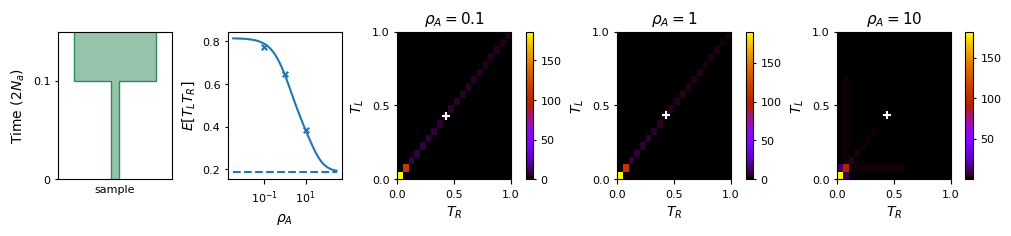

In [32]:
def plot_contraction_model(axs, fig):
    # takes an array of (5,) axs
    Na = 1e4
    builder = demes.Builder()
    builder.add_deme("sample", epochs=[{"start_size": Na, "end_time": 2e3},
                                   {"start_size": Na / 10, "end_time": 0}])
    graph = builder.resolve()

    # plot the graph
    demesdraw.tubes(graph, ax=axs[0], colours="seagreen", labels="xticks", inf_ratio=0.4)
    axs[0].spines["top"].set_visible(True)
    axs[0].spines["right"].set_visible(True)
    axs[0].spines["bottom"].set_visible(True)
    axs[0].set_yticks([0, 2e3], [0, 0.1])
    axs[0].set_ylim(0, 3e3)
    axs[0].set_ylabel("Time ($2N_a$)")
    axs[0].set_xlim(-7e3, 7e3)

    # plot moments expectations
    rhos = np.logspace(-2.5, 2.5, 50)
    yy = moments.Demes.LD(graph, ["sample"], rho=rhos, u=1)
    TTs = yy.H2(0) / 4 / (2 * Na) ** 2
    axs[1].plot(rhos, TTs)
    axs[1].set_xscale("log")
    axs[1].set_ylabel(r"$E[T_L T_R]$")
    axs[1].set_xlabel(r"$\rho_A$")

    # plot TL, TR
    num_reps = 100000
    samples = [msprime.SampleSet(2, ploidy=1, population="sample")]
    TlTrs = []
    focal_rho = [0.1, 1, 10]
    for idx, rho in zip([2, 3, 4], focal_rho):
        rr = rho / (4 * Na)
        times = retrieve_sim(graph, samples, rr, num_reps) / (2 * Na)
        *_, im = axs[idx].hist2d(times[:, 0], times[:, 1], bins=20, range=2*[[0, 1]], 
                                 cmap="gnuplot", norm="linear", density=True)
        fig.colorbar(im, ax=axs[idx])
        axs[idx].scatter([np.mean(times[:, 0])], [np.mean(times[:, 1])], color="white", marker="+")
        TlTr = np.mean(times[:, 0] * times[:, 1])
        TlTrs.append(TlTr)
        axs[idx].set_title(rf"$\rho_A={rho}$")
        axs[idx].set_ylabel("$T_L$")
        axs[idx].set_xlabel("$T_R$")
        axs[idx].set_xticks([0, 0.5, 1])
        axs[idx].set_yticks([0, 0.5, 1])
    
    axs[1].scatter(focal_rho, TlTrs, marker="x", s=16)
    axs[1].hlines([yy.H()[0] ** 2 / 4 / (2 * Na) ** 2], rhos[0], rhos[-1], colors=["tab:blue"], linestyles=["--"])
    axs[1].set_xticks([0.1, 10])


fig, axs = plt.subplots(1, 5, figsize=(10, 2.25), layout="constrained")
plot_contraction_model(axs, fig)

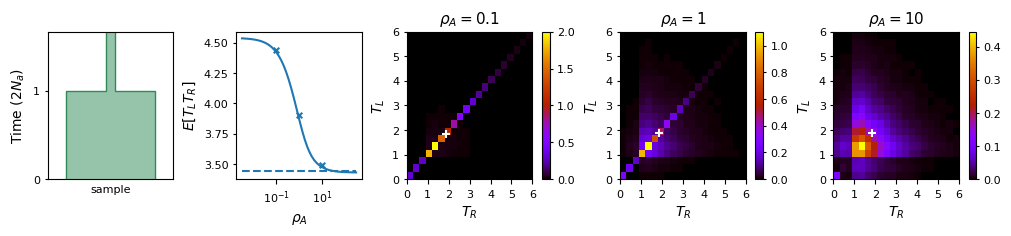

In [33]:
def plot_growth_model(axs, fig):
    # takes an array of (5,) axs
    Na = 1e4
    builder = demes.Builder()
    builder.add_deme("sample", epochs=[{"start_size": Na, "end_time": 2e4},
                                   {"start_size": Na * 10, "end_time": 0}])
    graph = builder.resolve()

    # plot the graph
    demesdraw.tubes(graph, ax=axs[0], colours="seagreen", labels="xticks", inf_ratio=0.4)
    axs[0].spines["top"].set_visible(True)
    axs[0].spines["right"].set_visible(True)
    axs[0].spines["bottom"].set_visible(True)
    axs[0].set_yticks([0, 2e4], [0, 1])
    axs[0].set_xlim(-7e4, 7e4)
    axs[0].set_ylabel("Time ($2N_a$)")

    # plot moments expectations
    rhos = np.logspace(-2.5, 2.5, 50)
    yy = moments.Demes.LD(graph, ["sample"], rho=rhos, u=1)
    TTs = yy.H2(0) / 4 / (2 * Na) ** 2
    axs[1].plot(rhos, TTs)
    axs[1].set_xscale("log")
    axs[1].set_ylabel(r"$E[T_L T_R]$")
    axs[1].set_xlabel(r"$\rho_A$")

    # plot TL, TR
    num_reps = 100000
    samples = [msprime.SampleSet(2, ploidy=1, population="sample")]
    TlTrs = []
    focal_rho = [0.1, 1, 10]
    for idx, rho in zip([2, 3, 4], focal_rho):
        rr = rho / (4 * Na)
        times = retrieve_sim(graph, samples, rr, num_reps) / (2 * Na)
        *_, im = axs[idx].hist2d(times[:, 0], times[:, 1], bins=20, range=2*[[0, 6]], 
                                 cmap="gnuplot", norm="linear", density=True)
        fig.colorbar(im, ax=axs[idx])
        axs[idx].scatter([np.mean(times[:, 0])], [np.mean(times[:, 1])], color="white", marker="+")
        TlTr = np.mean(times[:, 0] * times[:, 1])
        TlTrs.append(TlTr)
        axs[idx].set_title(rf"$\rho_A={rho}$")
        axs[idx].set_ylabel("$T_L$")
        axs[idx].set_xlabel("$T_R$")
        axs[idx].set_xticks(range(7))
        axs[idx].set_yticks(range(7))
    
    axs[1].scatter(focal_rho, TlTrs, marker="x", s=16)
    axs[1].hlines([yy.H()[0] ** 2 / 4 / (2 * Na) ** 2], rhos[0], rhos[-1], colors=["tab:blue"], linestyles=["--"])
    axs[1].set_xticks([0.1, 10])


fig, axs = plt.subplots(1, 5, figsize=(10, 2.25), layout="constrained")
plot_growth_model(axs, fig)

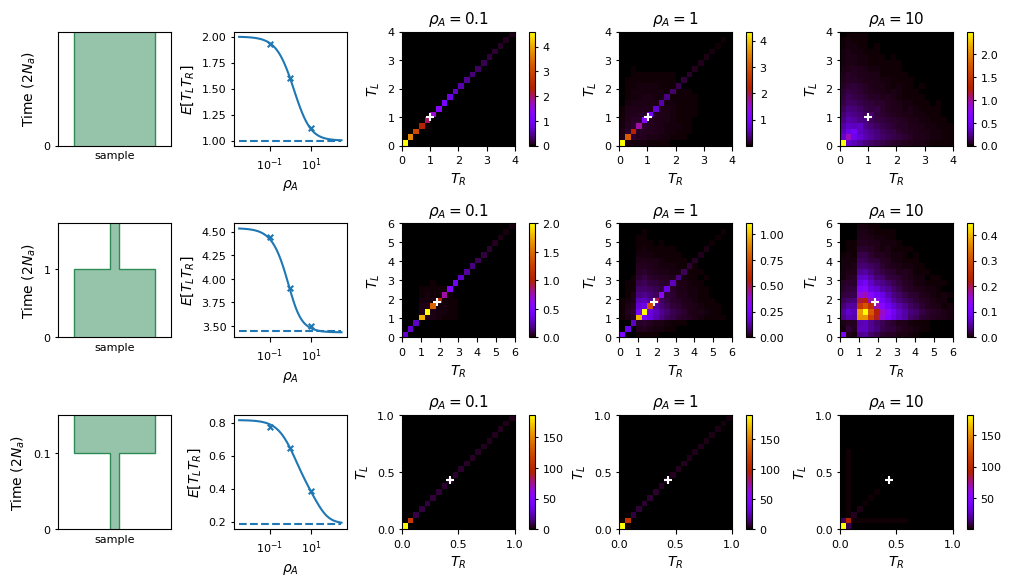

In [35]:
fig, axs = plt.subplots(3, 5, figsize=(10, 5.75), layout="constrained")
plot_equilibrium_model(axs[0], fig)
plot_growth_model(axs[1], fig)
plot_contraction_model(axs[2], fig)
plt.savefig("figures/joint_distr_size_change.pdf")

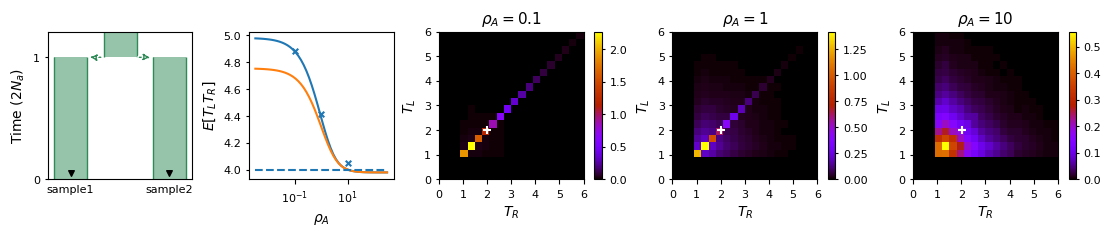

In [25]:
def plot_isolation_cross_model(axs, fig):
    # takes an array of (5,) axs
    Na = 1e4
    builder = demes.Builder()
    builder.add_deme("anc", epochs=[{"start_size": Na, "end_time": 2e4}])
    builder.add_deme("sample1", ancestors=["anc"], epochs=[{"start_size": Na, "end_time": 0}])
    builder.add_deme("sample2", ancestors=["anc"], epochs=[{"start_size": Na, "end_time": 0}])
    graph = builder.resolve()

    # plot the graph
    demesdraw.tubes(graph, ax=axs[0], log_time=True, colours="seagreen", labels="xticks",
                   positions={"anc": 0, "sample1": -1.5e4, "sample2": 1.5e4})
    axs[0].spines["top"].set_visible(True)
    axs[0].spines["right"].set_visible(True)
    axs[0].spines["bottom"].set_visible(True)
    axs[0].set_yscale("symlog")
    axs[0].set_yticks([0, 20000], [0, "1"]) 
    axs[0].set_yticks([], [], minor=True)
    axs[0].set_ylabel("Time ($2N_a$)")
    axs[0].scatter([-1.5e4, 1.5e4], [0.5, 0.5], marker="v", color="black", s=16)

    # plot moments expectations
    rhos = np.logspace(-2.5, 2.5, 50)
    yy = moments.Demes.LD(graph, ["sample1", "sample2"], rho=rhos, u=1)
    TTs = yy.H2(0, 1) / 4 / (2 * Na) ** 2
    axs[1].plot(rhos, TTs, label="phased")
    axs[1].set_xscale("log")
    axs[1].set_ylabel(r"$E[T_L T_R]$")
    axs[1].set_xlabel(r"$\rho_A$")
    # plot unphased
    TTs = yy.H2(0, 1, phased=False) / 4 / (2 * Na) ** 2
    axs[1].plot(rhos, TTs, label="unphased")
    # axs[1].legend(framealpha=0, fontsize="x-small")

    # plot TL, TR
    num_reps = 100000
    samples = [msprime.SampleSet(1, ploidy=1, population="sample1"),
               msprime.SampleSet(1, ploidy=1, population="sample2")]
    TlTrs = []
    focal_rho = [0.1, 1, 10]
    for idx, rho in zip([2, 3, 4], focal_rho):
        rr = rho / (4 * Na)
        times = retrieve_sim(graph, samples, rr, num_reps) / (2 * Na)
        *_, im = axs[idx].hist2d(times[:, 0], times[:, 1], bins=20, range=2*[[0, 6]], 
                                 cmap="gnuplot", norm="linear", density=True)
        fig.colorbar(im, ax=axs[idx])
        axs[idx].scatter([np.mean(times[:, 0])], [np.mean(times[:, 1])], color="white", marker="+")
        TlTr = np.mean(times[:, 0] * times[:, 1])
        TlTrs.append(TlTr)
        axs[idx].set_title(rf"$\rho_A={rho}$")
        axs[idx].set_ylabel("$T_L$")
        axs[idx].set_xlabel("$T_R$")
        axs[idx].set_xticks(range(7))
        axs[idx].set_yticks(range(7))
        
    axs[1].scatter(focal_rho, TlTrs, marker="x", s=16)
    axs[1].hlines([yy.H()[1] ** 2 / 4 / (2 * Na) ** 2], rhos[0], rhos[-1], colors=["tab:blue"], linestyles=["--"])
    axs[1].set_xticks([0.1, 10])


fig, axs = plt.subplots(1, 5, figsize=(11, 2.25), layout="constrained")
plot_isolation_cross_model(axs, fig)

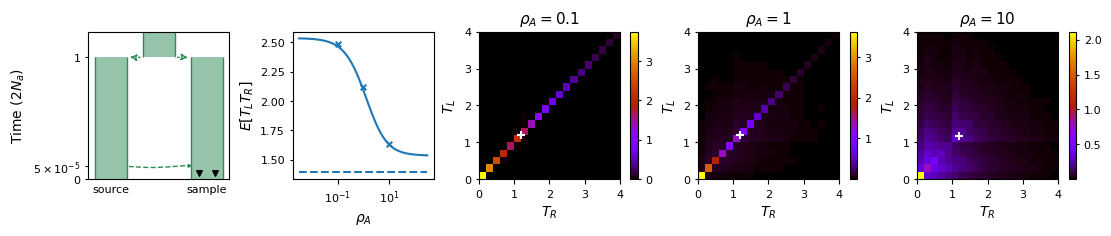

In [30]:
def plot_introgression_model(axs, fig):
    # takes an array of (5,) axs
    Na = 1e4
    builder = demes.Builder()
    builder.add_deme("anc", epochs=[{"start_size": Na, "end_time": 20001}])
    builder.add_deme("source", ancestors=["anc"], epochs=[{"start_size": Na, "end_time": 0}])
    builder.add_deme("sample", ancestors=["anc"], epochs=[{"start_size": Na, "end_time": 0}])
    builder.add_pulse(sources=["source"], dest="sample", proportions=[0.10], time=1)
    graph = builder.resolve()

    # plot the graph
    demesdraw.tubes(graph, ax=axs[0], log_time=True, colours="seagreen", labels="xticks",
                   positions={"anc": 0, "source": -1.5e4, "sample": 1.5e4})
    axs[0].spines["top"].set_visible(True)
    axs[0].spines["right"].set_visible(True)
    axs[0].spines["bottom"].set_visible(True)
    axs[0].set_yscale("symlog")
    axs[0].set_yticks([0, 1, 20001], [0, r"$5\times10^{-5}$", "1"]) 
    axs[0].set_yticks([], [], minor=True)
    axs[0].set_ylabel("Time ($2N_a$)")
    axs[0].scatter([1.75e4, 1.25e4], [0.5, 0.5], marker="v", color="black", s=16)

    # plot moments expectations
    rhos = np.logspace(-2.5, 2.5, 50)
    yy = moments.Demes.LD(graph, ["sample"], rho=rhos, u=1)
    TTs = yy.H2(0) / 4 / (2 * Na) ** 2
    axs[1].plot(rhos, TTs)
    axs[1].set_xscale("log")
    axs[1].set_ylabel(r"$E[T_L T_R]$")
    axs[1].set_xlabel(r"$\rho_A$")

    # plot TL, TR
    num_reps = 100000
    samples = [msprime.SampleSet(2, ploidy=1, population="sample")]
    TlTrs = []
    focal_rho = [0.1, 1, 10]
    for idx, rho in zip([2, 3, 4], focal_rho):
        rr = rho / (4 * Na)
        times = retrieve_sim(graph, samples, rr, num_reps) / (2 * Na)
        *_, im = axs[idx].hist2d(times[:, 0], times[:, 1], bins=20, range=2*[[0, 4]], 
                                 cmap="gnuplot", norm="linear", density=True)
        fig.colorbar(im, ax=axs[idx])
        axs[idx].scatter([np.mean(times[:, 0])], [np.mean(times[:, 1])], color="white", marker="+")
        TlTr = np.mean(times[:, 0] * times[:, 1])
        TlTrs.append(TlTr)
        axs[idx].set_title(rf"$\rho_A={rho}$")
        axs[idx].set_ylabel("$T_L$")
        axs[idx].set_xlabel("$T_R$")
        axs[idx].set_xticks(range(5))
        axs[idx].set_yticks(range(5))
    
    axs[1].scatter(focal_rho, TlTrs, marker="x", s=16)
    axs[1].hlines([yy.H()[0] ** 2 / 4 / (2 * Na) ** 2], rhos[0], rhos[-1], colors=["tab:blue"], linestyles=["--"])
    axs[1].set_xticks([0.1, 10])


fig, axs = plt.subplots(1, 5, figsize=(11, 2.25), layout="constrained")
plot_introgression_model(axs, fig)

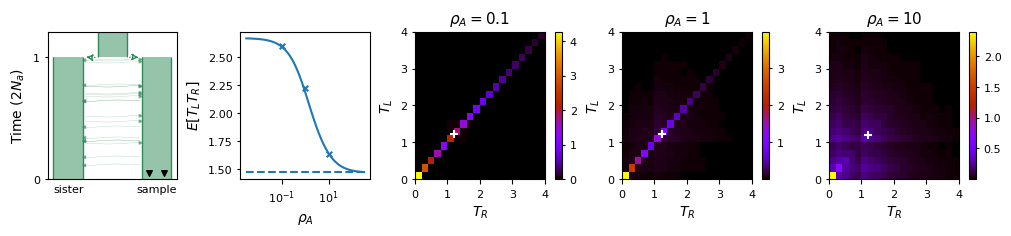

In [27]:
def plot_im_model(axs, fig):
    # takes an array of (5,) axs
    Na = 1e4
    M = 1
    m = M / (4 * Na)
    builder = demes.Builder()
    builder.add_deme("anc", epochs=[{"start_size": Na, "end_time": 2e4}])
    builder.add_deme("sample", ancestors=["anc"], epochs=[{"start_size": Na, "end_time": 0}])
    builder.add_deme("sister", ancestors=["anc"], epochs=[{"start_size": Na, "end_time": 0}])
    builder.add_migration(demes=["sample", "sister"], rate=m)
    graph = builder.resolve()

    # plot the graph
    demesdraw.tubes(graph, ax=axs[0], log_time=True, colours="seagreen", labels="xticks",
                   positions={"anc": 0, "sister": -1.5e4, "sample": 1.5e4})
    axs[0].spines["top"].set_visible(True)
    axs[0].spines["right"].set_visible(True)
    axs[0].spines["bottom"].set_visible(True)
    axs[0].set_yscale("symlog")
    axs[0].set_yticks([0, 20000], [0, "1"]) 
    axs[0].set_yticks([], [], minor=True)
    axs[0].set_ylabel("Time ($2N_a$)")
    axs[0].scatter([1.75e4, 1.25e4], [0.5, 0.5], marker="v", color="black", s=16)

    # plot moments expectations
    rhos = np.logspace(-2.5, 2.5, 50)
    yy = moments.Demes.LD(graph, ["sample"], rho=rhos, u=1)
    TTs = yy.H2(0) / 4 / (2 * Na) ** 2
    axs[1].plot(rhos, TTs)
    axs[1].set_xscale("log")
    axs[1].set_ylabel(r"$E[T_L T_R]$")
    axs[1].set_xlabel(r"$\rho_A$")

    # plot TL, TR
    num_reps = 100000
    samples = [msprime.SampleSet(2, ploidy=1, population="sample")]
    TlTrs = []
    focal_rho = [0.1, 1, 10]
    for idx, rho in zip([2, 3, 4], focal_rho):
        rr = rho / (4 * Na)
        times = retrieve_sim(graph, samples, rr, num_reps) / (2 * Na)
        *_, im = axs[idx].hist2d(times[:, 0], times[:, 1], bins=20, range=2*[[0, 4]], 
                                 cmap="gnuplot", norm="linear", density=True)
        fig.colorbar(im, ax=axs[idx])
        axs[idx].scatter([np.mean(times[:, 0])], [np.mean(times[:, 1])], color="white", marker="+")
        TlTr = np.mean(times[:, 0] * times[:, 1])
        TlTrs.append(TlTr)
        axs[idx].set_title(rf"$\rho_A={rho}$")
        axs[idx].set_ylabel("$T_L$")
        axs[idx].set_xlabel("$T_R$")
        axs[idx].set_xticks(range(5))
        axs[idx].set_yticks(range(5))
    
    axs[1].scatter(focal_rho, TlTrs, marker="x", s=16)
    axs[1].hlines([yy.H()[0] ** 2 / 4 / (2 * Na) ** 2], rhos[0], rhos[-1], colors=["tab:blue"], linestyles=["--"])
    axs[1].set_xticks([0.1, 10])


fig, axs = plt.subplots(1, 5, figsize=(10, 2.25), layout="constrained")
plot_im_model(axs, fig)

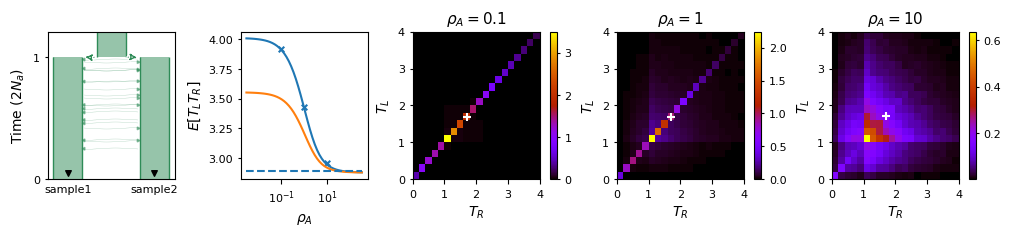

In [28]:
def plot_im_cross_model(axs, fig):
    # takes an array of (5,) axs
    Na = 1e4
    M = 1
    m = M / (4 * Na)
    builder = demes.Builder()
    builder.add_deme("anc", epochs=[{"start_size": Na, "end_time": 2e4}])
    builder.add_deme("sample1", ancestors=["anc"], epochs=[{"start_size": Na, "end_time": 0}])
    builder.add_deme("sample2", ancestors=["anc"], epochs=[{"start_size": Na, "end_time": 0}])
    builder.add_migration(demes=["sample1", "sample2"], rate=m)
    graph = builder.resolve()

    # plot the graph
    demesdraw.tubes(graph, ax=axs[0], log_time=True, colours="seagreen", labels="xticks",
                   positions={"anc": 0, "sample1": -1.5e4, "sample2": 1.5e4})
    axs[0].spines["top"].set_visible(True)
    axs[0].spines["right"].set_visible(True)
    axs[0].spines["bottom"].set_visible(True)
    axs[0].set_yscale("symlog")
    axs[0].set_yticks([0, 20000], [0, "1"]) 
    axs[0].set_yticks([], [], minor=True)
    axs[0].set_ylabel("Time ($2N_a$)")
    axs[0].scatter([-1.5e4, 1.5e4], [0.5, 0.5], marker="v", color="black", s=16)

    # plot moments expectations
    rhos = np.logspace(-2.5, 2.5, 50)
    yy = moments.Demes.LD(graph, ["sample1", "sample2"], rho=rhos, u=1)
    TTs = yy.H2(0, 1) / 4 / (2 * Na) ** 2
    axs[1].plot(rhos, TTs, label="phased")
    axs[1].set_xscale("log")
    axs[1].set_ylabel(r"$E[T_L T_R]$")
    axs[1].set_xlabel(r"$\rho_A$")
    # plot unphased
    TTs = yy.H2(0, 1, phased=False) / 4 / (2 * Na) ** 2
    axs[1].plot(rhos, TTs, label="unphased")
    # axs[1].legend(framealpha=0, fontsize="x-small")

    # plot TL, TR
    num_reps = 100000
    samples = [msprime.SampleSet(1, ploidy=1, population="sample1"),
               msprime.SampleSet(1, ploidy=1, population="sample2")]
    TlTrs = []
    focal_rho = [0.1, 1, 10]
    for idx, rho in zip([2, 3, 4], focal_rho):
        rr = rho / (4 * Na)
        times = retrieve_sim(graph, samples, rr, num_reps) / (2 * Na)
        *_, im = axs[idx].hist2d(times[:, 0], times[:, 1], bins=20, range=2*[[0, 4]], 
                                 cmap="gnuplot", norm="linear", density=True)
        fig.colorbar(im, ax=axs[idx])
        axs[idx].scatter([np.mean(times[:, 0])], [np.mean(times[:, 1])], color="white", marker="+")
        TlTr = np.mean(times[:, 0] * times[:, 1])
        TlTrs.append(TlTr)
        axs[idx].set_title(rf"$\rho_A={rho}$")
        axs[idx].set_ylabel("$T_L$")
        axs[idx].set_xlabel("$T_R$")
        axs[idx].set_xticks(range(5))
        axs[idx].set_yticks(range(5))
    
    axs[1].scatter(focal_rho, TlTrs, marker="x", s=16)
    axs[1].hlines([yy.H()[1] ** 2 / 4 / (2 * Na) ** 2], rhos[0], rhos[-1], colors=["tab:blue"], linestyles=["--"])
    axs[1].set_xticks([0.1, 10])


fig, axs = plt.subplots(1, 5, figsize=(10, 2.25), layout="constrained")
plot_im_cross_model(axs, fig)

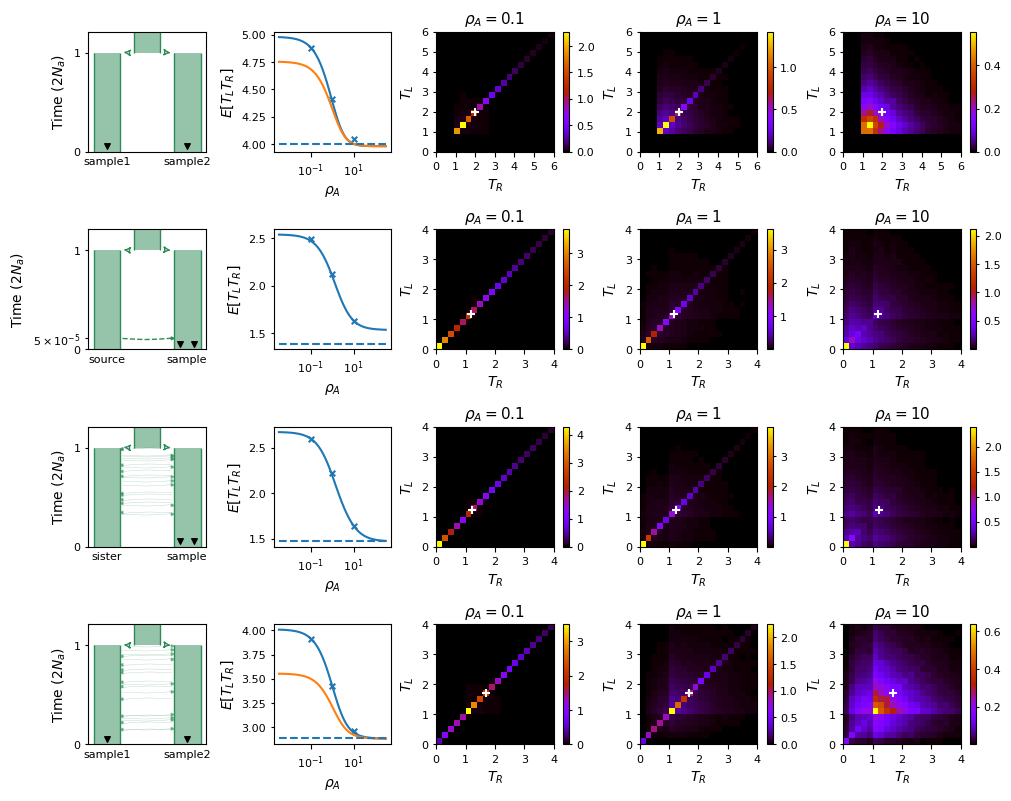

In [37]:
fig, axs = plt.subplots(4, 5, figsize=(10, 7.9), layout="constrained")
plot_isolation_cross_model(axs[0], fig)
plot_introgression_model(axs[1], fig)
plot_im_model(axs[2], fig)
plot_im_cross_model(axs[3], fig)
plt.savefig("figures/joint_distr_gene_flow.pdf")